<a href="https://colab.research.google.com/github/Golden028/PCVK/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D. PRAKTIKUM**

**D1. Operasi Citra Sederhana**

2. Akses folder images pada Google Drive Anda dengan kode berikut:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

3. Melakukan transformasi linier brightness dengan memasukkan nilai konstanta tertentu
dan menghasilkan warna. Seperti yang telah dibahas pada ulasan teori, formula untuk
melakukan transformasi linier brightness adalah sebagai berikut:

g(x, y) = f(x, y) + b

dimana g(x,y) adalah nilai pixel setelah transformasi, f(x,y) adalah nilai pixel asli, dan b adalah nilai brightness.
Tuliskan potongan kode berikut untuk mengimplementasikan linier brightness pada google colab:

Transoformasi Linier Drightness

Mengubah tingkat kecerahan citra
--------------------------------
Masukan tingkat kecerahan: 50


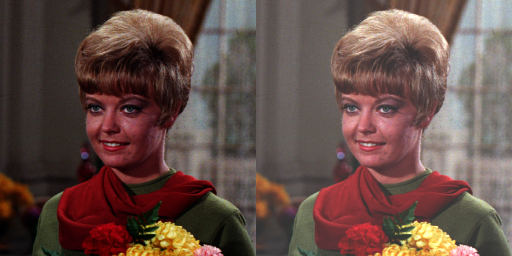

In [3]:
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
    brightness = int(input('Masukan tingkat kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

# for y in range(original.shape[0]):
#     for x in range(original.shape[1]):
#         for c in range(original.shape[2]):
#             brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

# Cara simple tanpa loop (lebih cepat, bisa dipakai juga)
brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)


**TUGAS PRAKTIKUM D1**

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

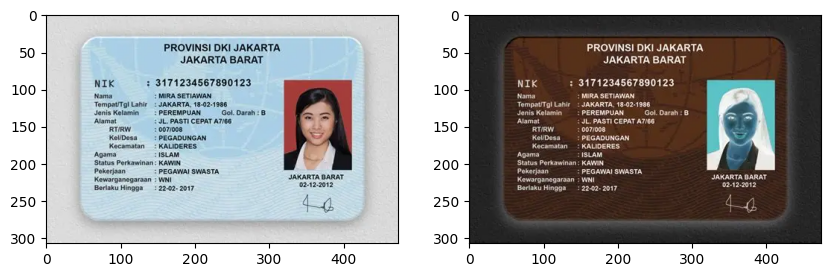

In [4]:
ktp = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')

ktp_rgb = cv.cvtColor(ktp, cv.COLOR_BGR2RGB)

# Invert the image: g(x) = 255 - f(x)
ktp_inverted = 255 - ktp_rgb

plt.figure(figsize=(10,10))

# final_frame = cv.hconcat([ktp, ktp_inverted])
# cv2_imshow(final_frame)

plt.subplot(1,2,1)
plt.imshow(ktp_rgb)

plt.subplot(1,2,2)
plt.imshow(ktp_inverted)
plt.show()

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:

Enter a brightness: 50
Enter a contrast: 2


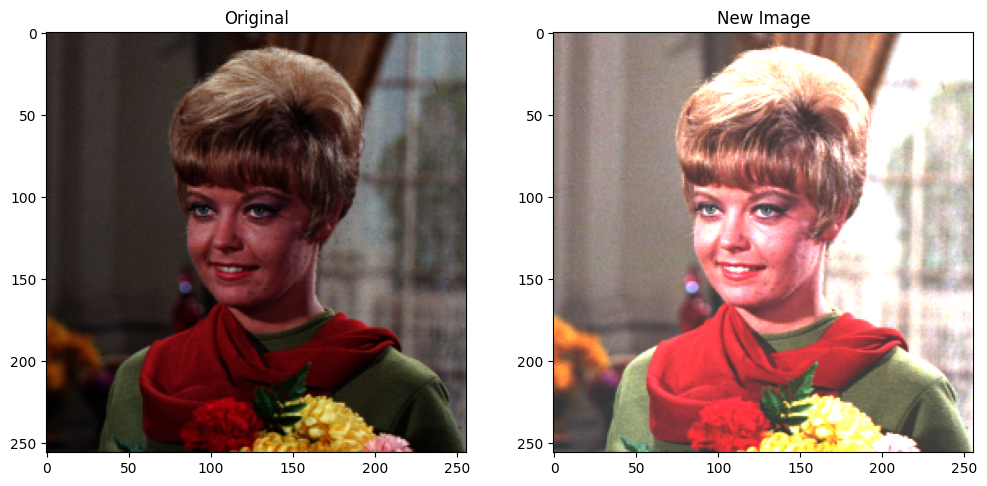

In [6]:
og2 = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
ogog2 = og2.copy()


try :
  brightness = int(input('Enter a brightness: '))
  contrast = float(input('Enter a contrast: '))
except ValueError:
  print('Error, not a number')

for y in range(og2.shape[0]):
  for x in range(og2.shape[1]):
    for c in range(og2.shape[2]):
      newimg = contrast * og2[y,x,c] + brightness
      og2[y,x,c] = np.clip  (newimg, 0, 255 )


plt.figure(figsize=(12,12))

plt.subplot(2,2,1)
plt.title('Original')
plt.imshow(cv.cvtColor(ogog2, cv.COLOR_BGR2RGB))

plt.subplot(2,2,2)
plt.title('New Image')
plt.imshow(cv.cvtColor(og2, cv.COLOR_BGR2RGB))

plt.tight_layout
plt.show()

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory
menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi
log, sehingga menghasilkan keluaran seperti berikut:

Mengubah tingkat kecerahan citra dengan Transformasi Log
-------------------------------------------------------
Masukan nilai kecerahan: 50


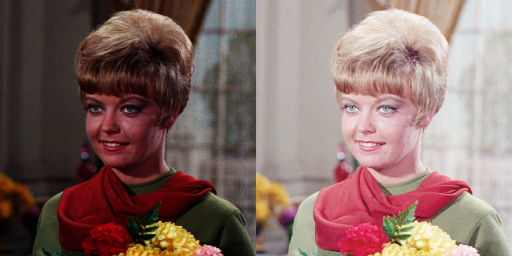

In [8]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('-------------------------------------------------------')

try:
  c = float(input('Masukan nilai kecerahan: '))
except ValueError:
  print('Error, not a number. Using default value.')

r = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')

# Apply the logarithmic transformation formula: g(x) = c * log(1 + f(x))
s = c * np.log(1 + r.astype(float))

# Normalize the result to the 0-255 range
# Find the maximum pixel value and scale all values
max_val = np.max(s)
s = (s / max_val) * 255

# Convert the image back to an 8-bit integer type
s = s.astype(np.uint8)

final_frame = cv.hconcat([r, s])
cv2_imshow(final_frame)

4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness,
dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada
bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

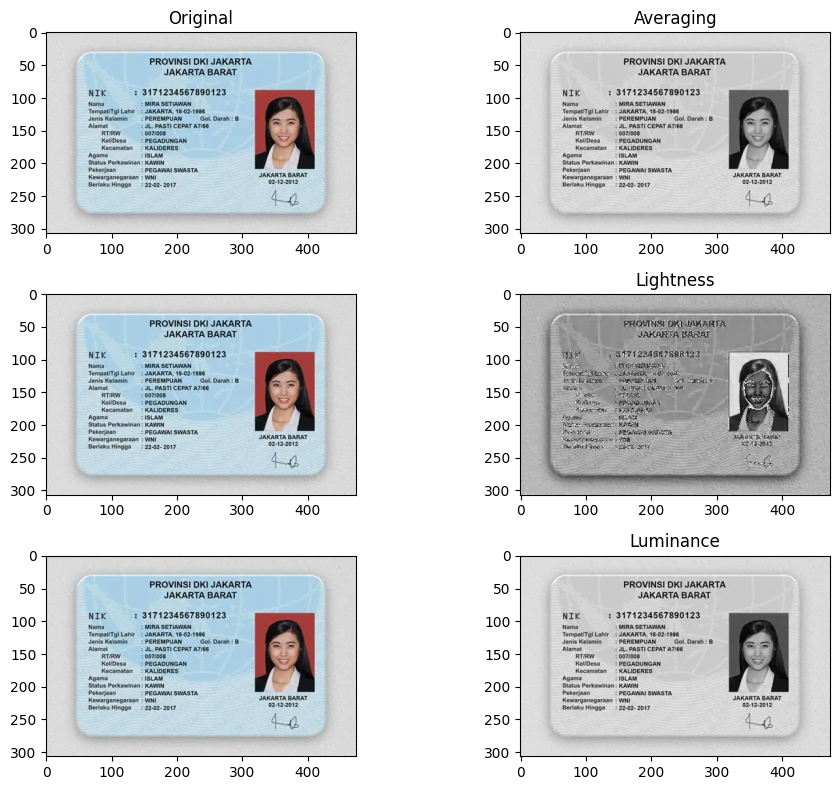

In [ ]:
ktp2 = ktp_rgb.copy()

# Get the R, G, and B channels
r, g, b = ktp2[:, :, 0], ktp2[:, :, 1], ktp2[:, :, 2]

# --- 1. Averaging Method ---
gray_avg = ((r.astype(float) + g.astype(float) + b.astype(float)) / 3).astype(np.uint8)

# --- 2. Lightness Method ---
gray_lightness = ((np.max(ktp2, axis=2) + np.min(ktp2, axis=2)) / 2).astype(np.uint8)

# --- 3. Luminance Method ---
gray_lum = (0.2126 * r.astype(float) + 0.7152 * g.astype(float) + 0.0722 * b.astype(float)).astype(np.uint8)

# --- Display with subplot (original vs grayscale) ---
plt.figure(figsize=(10, 8))

# Original vs Averaging
plt.subplot(3, 2, 1)
plt.imshow(ktp2)
plt.title("Original")

plt.subplot(3, 2, 2)
plt.imshow(gray_avg, cmap='gray')
plt.title("Averaging")

# Original vs Lightness
plt.subplot(3, 2, 3)
plt.imshow(ktp2)

plt.subplot(3, 2, 4)
plt.imshow(gray_lightness, cmap='gray')
plt.title("Lightness")

# Original vs Luminance
plt.subplot(3, 2, 5)
plt.imshow(ktp2)

plt.subplot(3, 2, 6)
plt.imshow(gray_lum, cmap='gray')
plt.title("Luminance")

plt.tight_layout()
plt.show()

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal,
tampilkan warna biru pada citra masukan dan ubah bagian lain yang tidak berwarna
biru menjadi grayscale seperti pada contoh berikut:

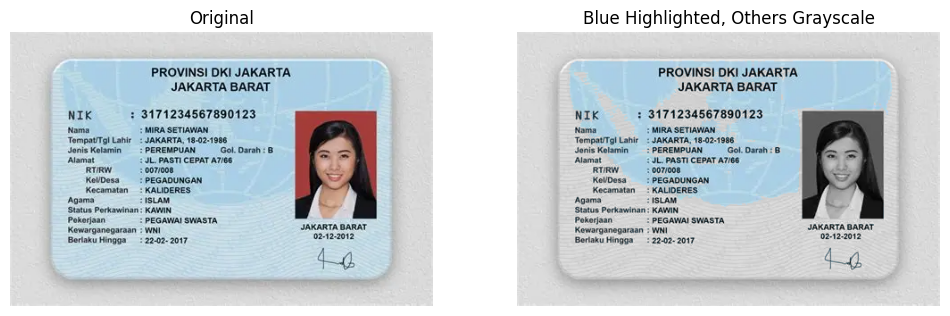

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/PCVK/Images/ktp.jpg'

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

mask = cv2.inRange(hsv, lower_blue, upper_blue)

blue_parts = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)

gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

result = np.where(blue_parts != 0, image_rgb, gray_3ch)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image_rgb)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(result)
ax[1].set_title("Blue Highlighted, Others Grayscale")
ax[1].axis("off")

plt.show()

D2. Operasi Aritmatika dan Logika

1.	Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image dengan gamma correction sesuai rumus yang telah diberikan.


=== GAMMA CORRECTION ===
Gamma Correction pada citra
----------------------------------
Masukkan nilai Gamma: 3


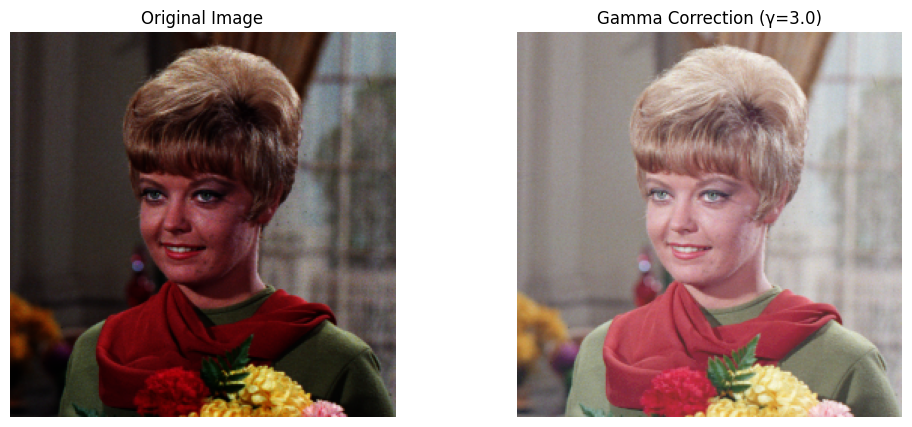

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def gamma_correction():
    print("=== GAMMA CORRECTION ===")
    print('Gamma Correction pada citra')
    print('----------------------------------')
    try:
        gamma = float(input('Masukkan nilai Gamma: '))
    except ValueError:
        print('Error, not a number')
        return

    original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
    gamma_img = np.zeros(original.shape, original.dtype)

    for i in range(original.shape[0]):
        for j in range(original.shape[1]):
            for k in range(original.shape[2]):
                normalized = original[i, j, k] / 255.0
                corrected = 255 * (normalized ** (1.0 / gamma))
                gamma_img[i, j, k] = np.clip(int(corrected), 0, 255)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(gamma_img, cv.COLOR_BGR2RGB))
    plt.title(f'Gamma Correction (γ={gamma})')
    plt.axis('off')
    plt.show()

gamma_correction()

2.	Buat Simulasi Image Depth
Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit). Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga 255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0 (000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit. Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.

Berikut adalah kode untuk membaca citra masukan dan memberi nilai kedalaman citra, silahkan lanjutkan kode program berikut sehingga menghasilkan keluaran seperti contoh pada Gambar.


=== SIMULASI BIT DEPTH ===
Masukkan bit depth (1-7): 2


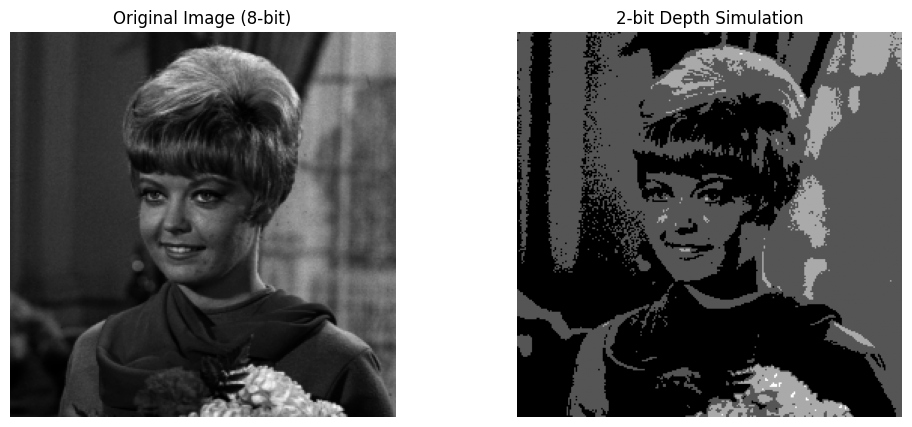

Bit depth: 2
Color levels: 4
Level value: 85.00


In [15]:
def bit_depth_simulation():
    print("=== SIMULASI BIT DEPTH ===")
    bit_depth = int(input('Masukkan bit depth (1-7): '))

    level = 255 / (pow(2, bit_depth) - 1)

    original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff', cv.IMREAD_GRAYSCALE)
    if original is None:
        print("Error loading image: /content/drive/MyDrive/PCVK/Images/female.tiff")
        return
    depth_image = np.zeros(original.shape, original.dtype)

    for i in range(original.shape[0]):
        for j in range(original.shape[1]):
            depth_image[i, j] = int(round((original[i, j] / level)) * level)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image (8-bit)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(depth_image, cmap='gray')
    plt.title(f'{bit_depth}-bit Depth Simulation')
    plt.axis('off')
    plt.show()

    print(f"Bit depth: {bit_depth}")
    print(f"Color levels: {pow(2, bit_depth)}")
    print(f"Level value: {level:.2f}")

from math import log10, sqrt
def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

bit_depth_simulation()

3.	Buat modul Average Denoising
Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab sebelumnya.
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,gunakan modul glob (import glob).

Dengan menggunakan code diatas, anda tinggal memanggil image difolder tersebut
menggunakan cv_img[0], cv_img[1], dst.
Catat hasil PSNR pada tabel berikut. Dari hasil yang sudah anda catat, tuliskan
kesimpulan anda:

Dari hasil PSNR yang anda catat pada tabel diatas, kesimpulan yang dapat diambil
adalah.


Jumlah noisy images: 1
Images averaged: 10, PSNR: 100.00 dB
Images averaged: 20, PSNR: 100.00 dB
Images averaged: 40, PSNR: 100.00 dB
Images averaged: 80, PSNR: 100.00 dB
Images averaged: 100, PSNR: 100.00 dB


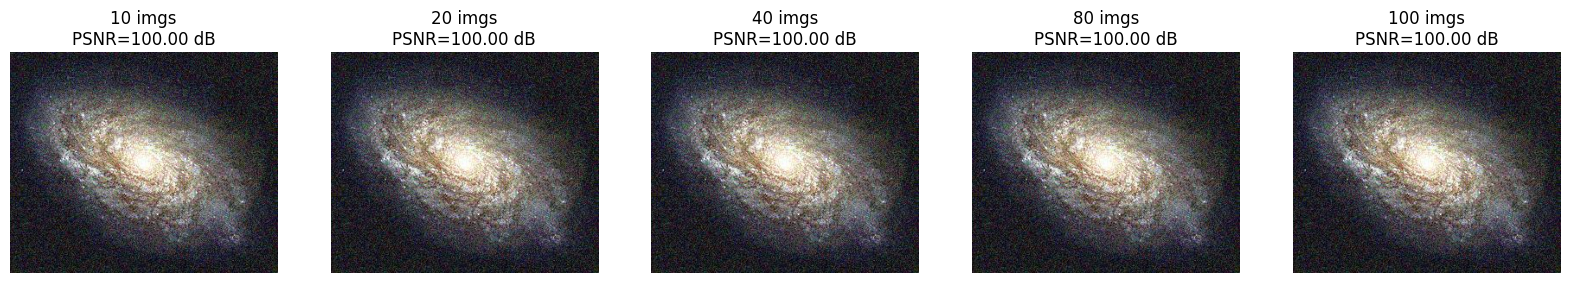

In [16]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

original = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/Images/galaxy.jpg'):
    n = cv.imread(img)
    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)
    cv_img.append(n)

print("Jumlah noisy images:", len(cv_img))

def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    return 20 * log10(max_pixel / sqrt(mse))

numbers = [10, 20, 40, 80, 100]
results = []
psnr_values = []

for num in numbers:
    avg_img = np.mean(cv_img[:num], axis=0).astype(np.uint8)
    psnr_value = PSNR(original, avg_img)
    results.append(avg_img)
    psnr_values.append(psnr_value)
    print(f"Images averaged: {num}, PSNR: {psnr_value:.2f} dB")

fig, axes = plt.subplots(1, len(numbers), figsize=(20, 5))

for i, ax in enumerate(axes):
    ax.imshow(results[i])
    ax.set_title(f"{numbers[i]} imgs\nPSNR={psnr_values[i]:.2f} dB")
    ax.axis("off")

plt.show()

4.	Buat image masking
Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff), sedangkan image paling kanan adalah hasilnya:

Lakukan percobaan menggunakan operator lain dan tunjukkan hasilnya pada modul ini.
Tuliskan hasil analisa anda kenapa citra keluarannya seperti itu.

Tuliskan hasil analisa anda:


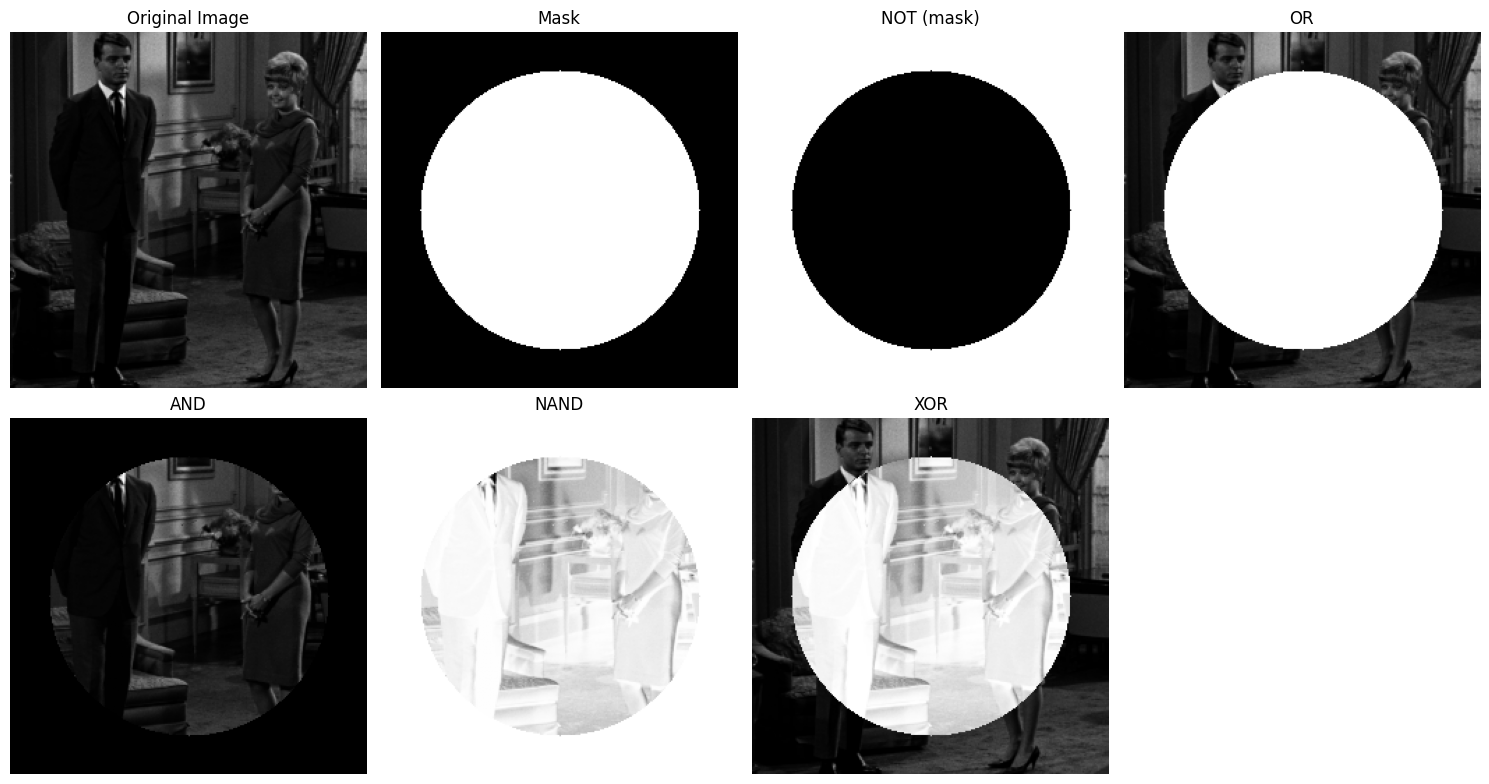

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff', 0)

mask = np.zeros_like(img, dtype=np.uint8)
cv.circle(mask, (img.shape[1]//2, img.shape[0]//2), 100, 255, -1)

not_mask = cv.bitwise_not(mask)                # NOT
or_result = cv.bitwise_or(img, mask)           # OR
and_result = cv.bitwise_and(img, mask)         # AND
nand_result = cv.bitwise_not(and_result)       # NAND
xor_result = cv.bitwise_xor(img, mask)         # XOR

titles = ["Original Image", "Mask",
          "NOT (mask)", "OR", "AND", "NAND", "XOR"]
images = [img, mask, not_mask, or_result, and_result, nand_result, xor_result]

plt.figure(figsize=(15, 8))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()